# Malnutrition Prediction (Classification) — Google Colab Notebook
This notebook follows a **step-by-step workflow similar to your heart-disease example**: import → explore → clean/noise check → split → normalize → train & tune models → evaluate → conclude.

**Dataset path (already mounted here):** `/mnt/data/malnutrition_data .csv`

In [1]:
# 1) Import Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Optional: show more columns when printing
pd.set_option("display.max_columns", 200)


In [2]:
# 2) Import Dataset
DATA_PATH = "malnutrition_data.csv"  # <- change only if your file path differs in Colab

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(10)


Shape: (5000, 6)


,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.345052,3.000000,54.134002,13.160919,10.0,normal
1,30.807200,5.459076,76.199180,13.944380,10.0,normal
2,15.723226,3.000000,60.280820,13.243565,10.0,normal
3,57.796256,10.103074,104.990471,14.105683,10.0,normal
4,40.321320,7.110583,85.277902,14.641630,10.0,normal
5,46.165261,7.874931,94.017390,13.834583,10.0,normal
6,46.925470,5.698782,93.416328,12.339353,10.0,moderate
7,53.143367,9.203581,99.657858,13.271861,10.0,normal
8,31.812352,5.547002,77.008247,13.958708,10.0,normal
9,47.561103,8.346381,96.525702,13.992754,10.0,normal


## 3) Data Preprocessing
### 3.1 Dataset overview (`describe`-style summary)

In [3]:
def describe_table(dataframe: pd.DataFrame) -> pd.DataFrame:
    variables, dtypes, count, unique, missing, min_, max_ = [], [], [], [], [], [], []
    for col in dataframe.columns:
        variables.append(col)
        dtypes.append(dataframe[col].dtype)
        count.append(len(dataframe[col]))
        unique.append(dataframe[col].nunique())
        missing.append(int(dataframe[col].isna().sum()))
        if pd.api.types.is_numeric_dtype(dataframe[col]):
            min_.append(float(dataframe[col].min()))
            max_.append(float(dataframe[col].max()))
        else:
            min_.append("Str")
            max_.append("Str")
    return pd.DataFrame({
        "variable": variables,
        "dtype": dtypes,
        "count": count,
        "unique": unique,
        "missing_value": missing,
        "Min": min_,
        "Max": max_
    })

desc = describe_table(df)
desc


,variable,dtype,count,unique,missing_value,Min,Max
0,age_months,float64,5000,5000,0,1.000686,59.989601
1,weight_kg,float64,5000,3383,0,3.0,10.726919
2,height_cm,float64,5000,4791,0,45.0,105.0
3,muac_cm,float64,5000,5000,0,10.261992,15.715103
4,bmi,float64,5000,83,0,10.0,11.285436
5,nutrition_status,str,5000,3,0,Str,Str


### 3.2 Target & feature columns
Your dataset has these columns:
- **Features:** `age_months, weight_kg, height_cm, muac_cm, bmi`
- **Target:** `nutrition_status` (example values: `normal`, `moderate`, `severe`)

In [4]:
# Auto-detect target (works even if you rename columns later)
possible_targets = ["nutrition_status", "target", "output", "label", "class", "y"]
target_col = next((c for c in possible_targets if c in df.columns), df.columns[-1])

feature_cols = [c for c in df.columns if c != target_col]
print("Target column:", target_col)
print("Feature columns:", feature_cols)

df[target_col].value_counts()


Target column: nutrition_status
Feature columns: ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi']


nutrition_status
normal      3550
moderate    1100
severe       350
Name: count, dtype: int64

### 3.3 Missing values + quick fixes

In [5]:
# Missing values check
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


Series([], dtype: int64)

In [6]:
# If there are missing numeric values, fill with median (safe default).
# If you don't have missing values, this cell won't change anything.
for c in feature_cols:
    if pd.api.types.is_numeric_dtype(df[c]) and df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

# If target is missing, drop those rows
df = df.dropna(subset=[target_col]).reset_index(drop=True)

print("Shape after missing-handling:", df.shape)


Shape after missing-handling: (5000, 6)


### 3.4 Noise / outlier detection with boxplots (similar to your example)

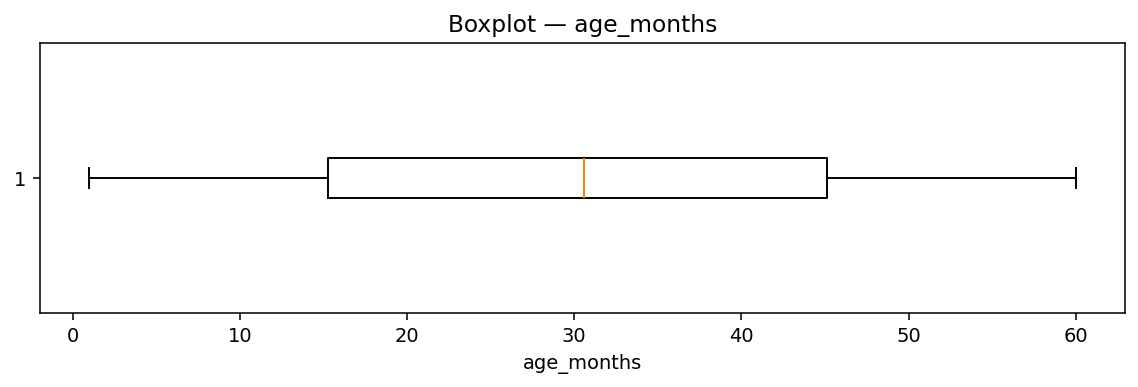

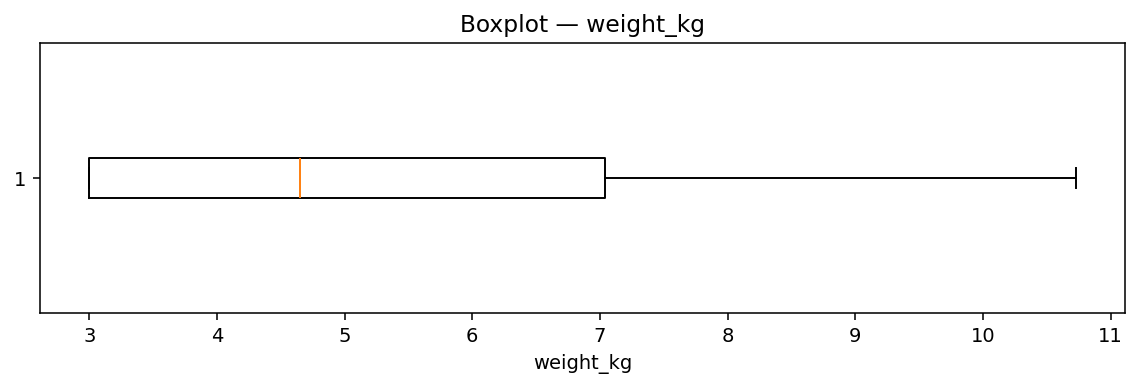

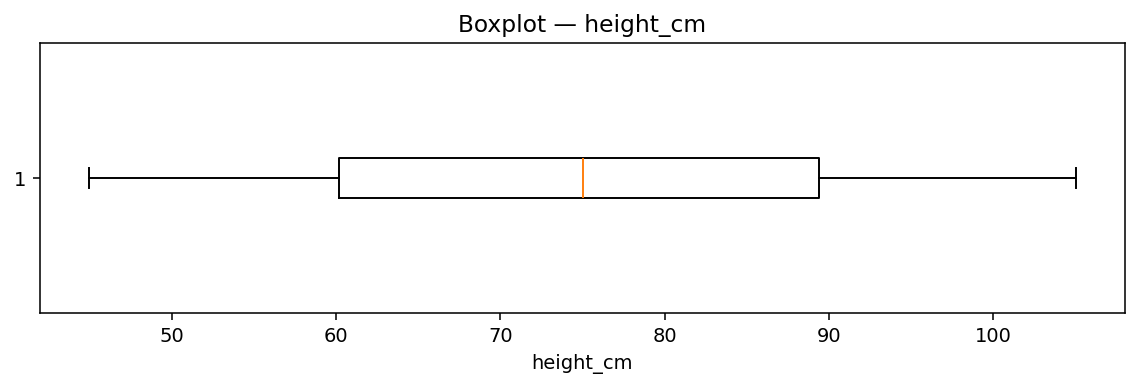

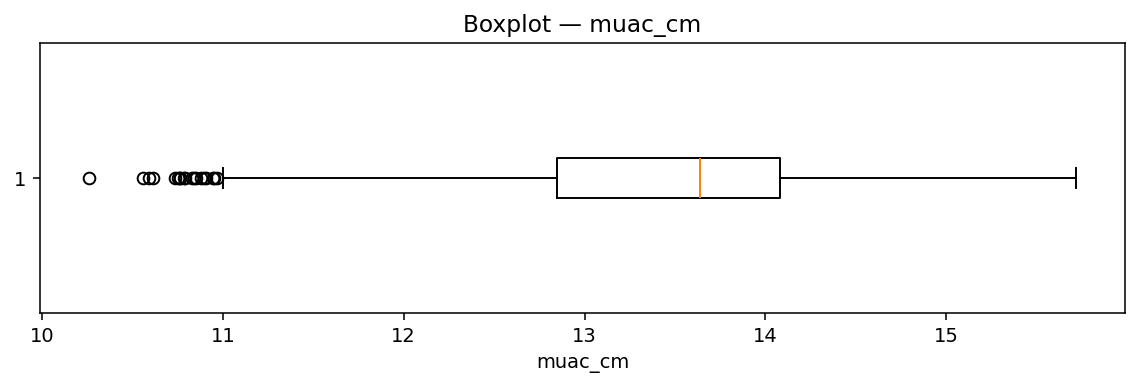

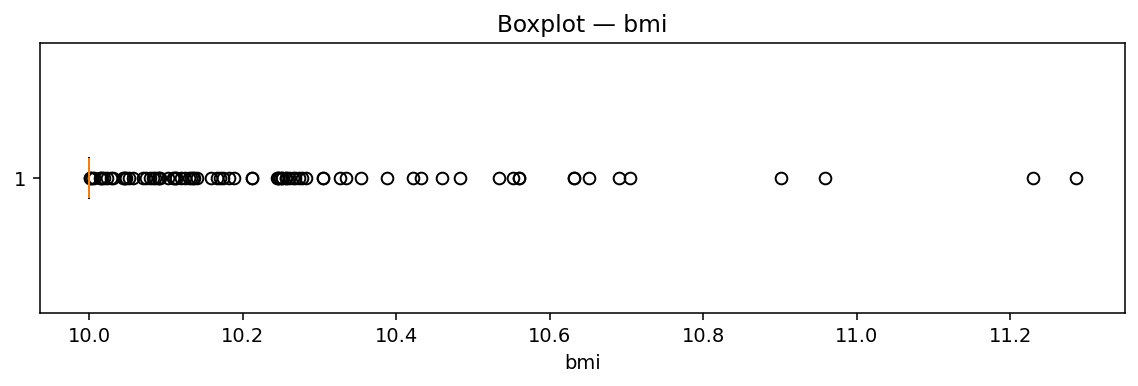

In [7]:
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

for c in num_cols:
    plt.figure(figsize=(10, 2.5), dpi=140)
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f"Boxplot — {c}")
    plt.xlabel(c)
    plt.show()


### 3.5 Optional: Drop extreme outliers using IQR rule
If your model becomes unstable, you can remove extreme outliers. This is optional — try **without** dropping first.

In [8]:
def drop_iqr_outliers(dataframe: pd.DataFrame, cols, factor: float = 3.0) -> pd.DataFrame:
    # factor=1.5 is strict; 3.0 is more conservative
    clean = dataframe.copy()
    for c in cols:
        if not pd.api.types.is_numeric_dtype(clean[c]):
            continue
        q1 = clean[c].quantile(0.25)
        q3 = clean[c].quantile(0.75)
        iqr = q3 - q1
        lo = q1 - factor * iqr
        hi = q3 + factor * iqr
        clean = clean[(clean[c] >= lo) & (clean[c] <= hi)]
    return clean.reset_index(drop=True)

# Uncomment if you want to apply outlier removal:
# df = drop_iqr_outliers(df, num_cols, factor=3.0)
# print("Shape after outlier removal:", df.shape)


### 3.6 Encode target + split dataset
Because the target is text (e.g., `normal/moderate/severe`), we encode it to integers.

In [9]:
# Encode target labels (multiclass)
le = LabelEncoder()
y = le.fit_transform(df[target_col])

X = df[feature_cols].copy()

print("Classes mapping:", dict(zip(le.classes_, range(len(le.classes_)))))
print("X shape:", X.shape, "| y shape:", y.shape)

# Train/test split (stratified keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40, stratify=y
)


Classes mapping: {'moderate': 0, 'normal': 1, 'severe': 2}
X shape: (5000, 5) | y shape: (5000,)


### 3.7 Normalize features (MinMaxScaler)

In [10]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Quick check
X_train_scaled[:3]


array([[0.90085949, 0.85408516, 0.91729847, 0.64109446, 0.        ],
       [0.2273007 , 0.        , 0.24388062, 0.54190462, 0.        ],
       [0.60130931, 0.23213893, 0.54853091, 0.44805741, 0.        ]])

## 4) Machine Learning Models + Hyperparameter Tuning
We tune models using **GridSearchCV** (cleaner than manual loops, but same idea: try many settings and choose the best).

In [11]:
def evaluate_model(name, model, X_te, y_te):
    pred = model.predict(X_te)
    acc = accuracy_score(y_te, pred)
    f1m = f1_score(y_te, pred, average="macro")
    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(f1m, 4))
    print("\nClassification report:")
    print(classification_report(y_te, pred, target_names=le.classes_))

    cm = confusion_matrix(y_te, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()
    return acc, f1m


### 4.1 KNN (tune `n_neighbors`, `p`, `weights`)

Best KNN params: {'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}

=== KNN ===
Accuracy: 0.958
Macro F1: 0.8974

Classification report:
              precision    recall  f1-score   support

    moderate       0.89      0.92      0.91       220
      normal       0.99      0.99      0.99       710
      severe       0.84      0.76      0.80        70

    accuracy                           0.96      1000
   macro avg       0.91      0.89      0.90      1000
weighted avg       0.96      0.96      0.96      1000



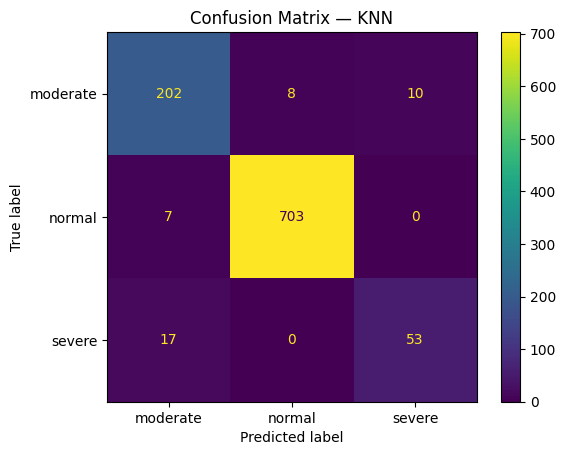

In [12]:
knn = KNeighborsClassifier()

param_grid_knn = {
    "n_neighbors": list(range(3, 31, 2)),
    "p": [1, 2],                 # Manhattan vs Euclidean
    "weights": ["uniform", "distance"]
}

gs_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring="f1_macro", n_jobs=-1)
gs_knn.fit(X_train_scaled, y_train)

print("Best KNN params:", gs_knn.best_params_)
best_knn = gs_knn.best_estimator_

acc_knn, f1_knn = evaluate_model("KNN", best_knn, X_test_scaled, y_test)


### 4.2 SVM (tune `C`, `kernel`, `gamma`)

Best SVM params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

=== SVM ===
Accuracy: 0.965
Macro F1: 0.928

Classification report:
              precision    recall  f1-score   support

    moderate       0.92      0.92      0.92       220
      normal       0.99      0.99      0.99       710
      severe       0.90      0.86      0.88        70

    accuracy                           0.96      1000
   macro avg       0.93      0.92      0.93      1000
weighted avg       0.96      0.96      0.96      1000



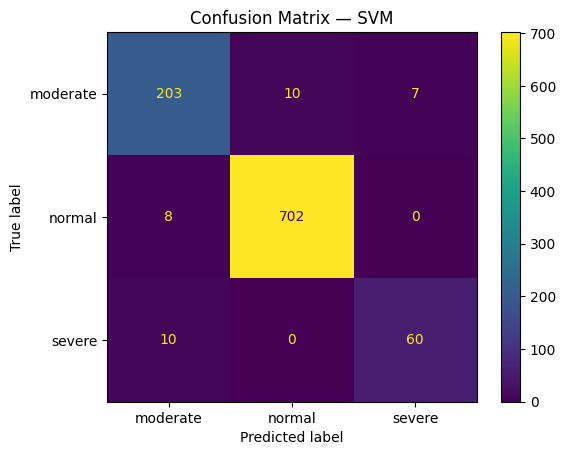

In [13]:
svm = SVC()

param_grid_svm = [
    {"kernel": ["linear"], "C": [0.1, 0.5, 1, 2, 5, 10]},
    {"kernel": ["rbf"], "C": [0.1, 0.5, 1, 2, 5, 10], "gamma": ["scale", "auto"]},
    {"kernel": ["poly"], "C": [0.1, 0.5, 1, 2, 5], "degree": [2, 3]}
]

gs_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring="f1_macro", n_jobs=-1)
gs_svm.fit(X_train_scaled, y_train)

print("Best SVM params:", gs_svm.best_params_)
best_svm = gs_svm.best_estimator_

acc_svm, f1_svm = evaluate_model("SVM", best_svm, X_test_scaled, y_test)


### 4.3 Decision Tree (tune `max_depth`, `min_samples_split`, `criterion`)

Best DT params: {'criterion': 'entropy', 'max_depth': 11, 'min_samples_split': 2}

=== Decision Tree ===
Accuracy: 0.935
Macro F1: 0.8447

Classification report:
              precision    recall  f1-score   support

    moderate       0.84      0.87      0.85       220
      normal       0.98      0.98      0.98       710
      severe       0.76      0.64      0.70        70

    accuracy                           0.94      1000
   macro avg       0.86      0.83      0.84      1000
weighted avg       0.93      0.94      0.93      1000



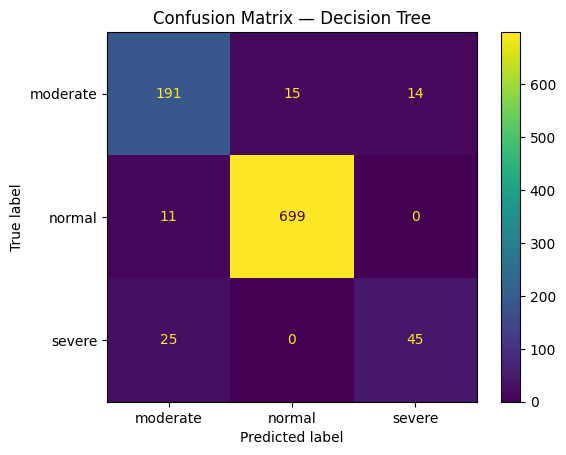

In [14]:
dt = DecisionTreeClassifier(random_state=40)

param_grid_dt = {
    "max_depth": list(range(2, 21)),
    "min_samples_split": [2, 5, 10, 20],
    "criterion": ["gini", "entropy", "log_loss"]
}

gs_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring="f1_macro", n_jobs=-1)
gs_dt.fit(X_train_scaled, y_train)

print("Best DT params:", gs_dt.best_params_)
best_dt = gs_dt.best_estimator_

acc_dt, f1_dt = evaluate_model("Decision Tree", best_dt, X_test_scaled, y_test)


### 4.4 Random Forest (tune `n_estimators`, `max_depth`, `min_samples_split`)

Best RF params: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_split': 5, 'n_estimators': 100}

=== Random Forest ===
Accuracy: 0.949
Macro F1: 0.8796

Classification report:
              precision    recall  f1-score   support

    moderate       0.88      0.89      0.88       220
      normal       0.98      0.99      0.99       710
      severe       0.83      0.71      0.77        70

    accuracy                           0.95      1000
   macro avg       0.90      0.86      0.88      1000
weighted avg       0.95      0.95      0.95      1000



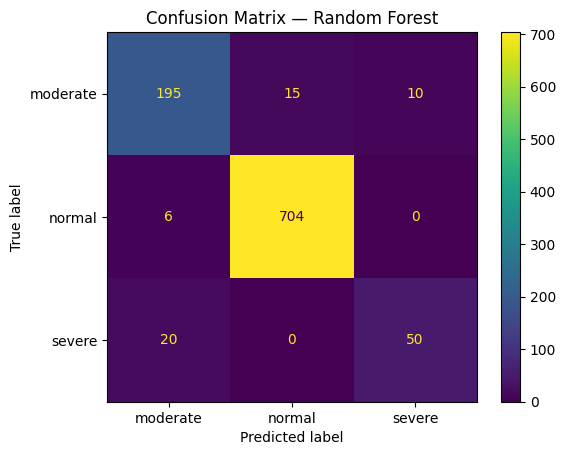

In [15]:
rf = RandomForestClassifier(random_state=40)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 3, 5, 8, 12],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

gs_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring="f1_macro", n_jobs=-1)
gs_rf.fit(X_train_scaled, y_train)

print("Best RF params:", gs_rf.best_params_)
best_rf = gs_rf.best_estimator_

acc_rf, f1_rf = evaluate_model("Random Forest", best_rf, X_test_scaled, y_test)


## 5) Conclusion: Compare best models

In [16]:
results = pd.DataFrame({
    "model": ["KNN", "SVM", "Decision Tree", "Random Forest"],
    "accuracy": [acc_knn, acc_svm, acc_dt, acc_rf],
    "macro_f1": [f1_knn, f1_svm, f1_dt, f1_rf],
}).sort_values(by="macro_f1", ascending=False)

results


,model,accuracy,macro_f1
1,SVM,0.965,0.927963
0,KNN,0.958,0.897422
3,Random Forest,0.949,0.879630
2,Decision Tree,0.935,0.844667


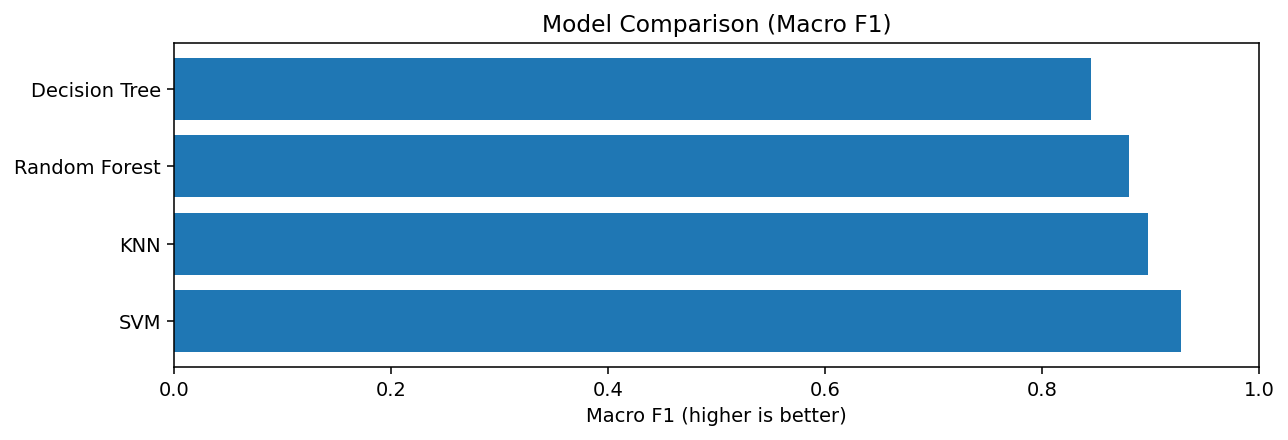

In [17]:
plt.figure(figsize=(10, 3), dpi=140)
plt.barh(results["model"], results["macro_f1"])
plt.xlabel("Macro F1 (higher is better)")
plt.title("Model Comparison (Macro F1)")
plt.xlim(0, 1.0)
plt.show()


### Save trained model (optional)
If you want to deploy later, you can save the scaler + best model with `joblib`.

In [18]:
import joblib

best_row = results.iloc[0]
print("Best model by Macro F1:", best_row["model"])

best_model_map = {
    "KNN": best_knn,
    "SVM": best_svm,
    "Decision Tree": best_dt,
    "Random Forest": best_rf
}

final_model = best_model_map[best_row["model"]]

joblib.dump({"scaler": scaler, "label_encoder": le, "model": final_model}, "malnutrition_model.joblib")
print("Saved -> malnutrition_model.joblib")


Best model by Macro F1: SVM
Saved -> malnutrition_model.joblib
